In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets

In [21]:
url = r'C:\Users\okkk\Desktop\python programming project\twitterdata.csv'
df = pd.read_csv(url, encoding='cp1252')

In [22]:
df.head(10)

,polarity of tweet,id of the tweet,date of the tweet,query,user,text of the tweet
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew
5,0,1467811592,Mon Apr 06 22:20:03 PDT 2009,NO_QUERY,mybirch,Need a hug
6,0,1467811594,Mon Apr 06 22:20:03 PDT 2009,NO_QUERY,coZZ,@LOLTrish hey long time no see! Yes.. Rains a...
7,0,1467812579,Mon Apr 06 22:20:17 PDT 2009,NO_QUERY,pardonlauren,I just re-pierced my ears
8,0,1467812723,Mon Apr 06 22:20:19 PDT 2009,NO_QUERY,TLeC,@caregiving I couldn't bear to watch it. And ...
9,0,1467812771,Mon Apr 06 22:20:19 PDT 2009,NO_QUERY,robrobbierobert,"@octolinz16 It it counts, idk why I did either..."


In [23]:
df.shape

(1048572, 6)

In [24]:
# Data Collection
import pandas as pd

# Load the CSV file
df = pd.read_csv(
    r'C:\Users\okkk\Desktop\python programming project\twitterdata.csv',
    encoding='latin-1',
    low_memory=False,
    dtype=str
)

# Rename columns to exactly match your dataset headers
df.columns = [
    'polarity of tweet',
    'id of the tweet',
    'date of the tweet',
    'query',
    'user',
    'text of the tweet'
]

# Display first few rows
print("Sample Data:")
print(df.head(10))

# Keep only relevant columns for sentiment analysis
df = df[['polarity of tweet', 'text of the tweet']]

# Convert polarity numbers to readable labels
# 0 = negative, 2 = neutral, 4 = positive
df['polarity of tweet'] = df['polarity of tweet'].map({'0': 'negative', '2': 'neutral', '4': 'positive'})

# Display sentiment distribution
print("\nSentiment Distribution:")
print(df['polarity of tweet'].value_counts())



Sample Data:
  polarity of tweet id of the tweet             date of the tweet     query  \
0                 0      1467810672  Mon Apr 06 22:19:49 PDT 2009  NO_QUERY   
1                 0      1467810917  Mon Apr 06 22:19:53 PDT 2009  NO_QUERY   
2                 0      1467811184  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY   
3                 0      1467811193  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY   
4                 0      1467811372  Mon Apr 06 22:20:00 PDT 2009  NO_QUERY   
5                 0      1467811592  Mon Apr 06 22:20:03 PDT 2009  NO_QUERY   
6                 0      1467811594  Mon Apr 06 22:20:03 PDT 2009  NO_QUERY   
7                 0      1467812579  Mon Apr 06 22:20:17 PDT 2009  NO_QUERY   
8                 0      1467812723  Mon Apr 06 22:20:19 PDT 2009  NO_QUERY   
9                 0      1467812771  Mon Apr 06 22:20:19 PDT 2009  NO_QUERY   

              user                                  text of the tweet  
0    scotthamilton  is upset that he can't up

In [25]:
!pip install nltk


[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [26]:
#data preprocessing
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

#download NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
#initialize stopwords and lemmatizer
stop_words=set(stopwords.words('english'))
lemmatizer=WordNetLemmatizer()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\okkk\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\okkk\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\okkk\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [27]:
#Functions to clean twitter or tweet text
def clean_tweet(text):
    text = str(text).lower()                          # Lowercase
    text = re.sub(r'http\S+|www.\S+', '', text)       # Remove URLs
    text = re.sub(r'@\w+', '', text)                  # Remove mentions
    text = re.sub(r'#', '', text)                     # Remove hashtag symbols
    text = re.sub(r'[^a-z\s]', '', text)              # Remove non-alphabetic characters
    text = re.sub(r'\s+', ' ', text).strip()          # Remove extra spaces
    return text

In [28]:
#apply cleaning
df['clean text']=df['text of the tweet'].apply(clean_tweet)


In [29]:
#removing stopwords and lemmatize using the functions
def preprocess_text(text):
    words=text.split()
    words=[lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return ' '.join(words)

In [30]:
#applying the preprocessing
df['clean_text'] = df['text of the tweet'].apply(clean_tweet)
df['processed_text'] = df['clean_text'].apply(preprocess_text)


In [31]:
# Show before and after examples
print("\nBefore and After Cleaning:")
for i in range(3):
    print(f"\nOriginal: {df['text of the tweet'][i]}")
    print(f"Processed: {df['processed_text'][i]}")

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())


Before and After Cleaning:

Original: is upset that he can't update his Facebook by texting it... and might cry as a result  School today also. Blah!
Processed: upset cant update facebook texting might cry result school today also blah

Original: @Kenichan I dived many times for the ball. Managed to save 50%  The rest go out of bounds
Processed: dived many time ball managed save rest go bound

Original: my whole body feels itchy and like its on fire 
Processed: whole body feel itchy like fire

Missing Values:
polarity of tweet    0
text of the tweet    0
clean text           0
clean_text           0
processed_text       0
dtype: int64


In [32]:
# Importing the  display function
from IPython.display import display
#selecting the rows to display
comparison = df[['text of the tweet', 'processed_text']].head(20)
# Apply styling 
styled_table = comparison.style.set_properties(**{
    'white-space': 'pre-wrap',
    'width': '400px',            
    'text-align': 'left',        
    'font-size': '12px'          
})
display(styled_table)


,text of the tweet,processed_text
0,is upset that he can't update his Facebook by texting it... and might cry as a result School today also. Blah!,upset cant update facebook texting might cry result school today also blah
1,@Kenichan I dived many times for the ball. Managed to save 50% The rest go out of bounds,dived many time ball managed save rest go bound
2,my whole body feels itchy and like its on fire,whole body feel itchy like fire
3,"@nationwideclass no, it's not behaving at all. i'm mad. why am i here? because I can't see you all over there.",behaving im mad cant see
4,@Kwesidei not the whole crew,whole crew
5,Need a hug,need hug
6,"@LOLTrish hey long time no see! Yes.. Rains a bit ,only a bit LOL , I'm fine thanks , how's you ?",hey long time see yes rain bit bit lol im fine thanks hows
7,I just re-pierced my ears,repierced ear
8,@caregiving I couldn't bear to watch it. And I thought the UA loss was embarrassing . . . . .,couldnt bear watch thought ua loss embarrassing
9,"@octolinz16 It it counts, idk why I did either. you never talk to me anymore",count idk either never talk anymore


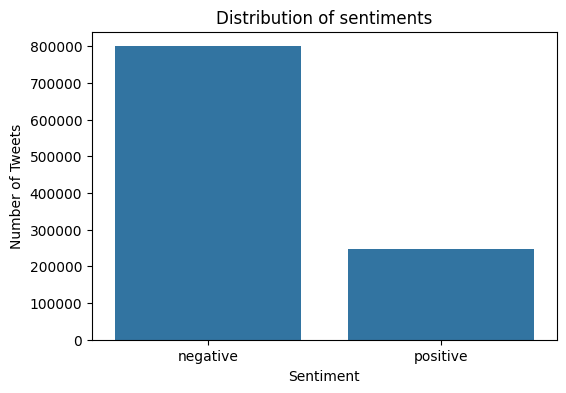

In [33]:
#EDA PROCESS
#Sentiment distribution
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6,4))
sns.countplot(x='polarity of tweet',data=df)
plt.title('Distribution of sentiments')
plt.xlabel('Sentiment')
plt.ylabel('Number of Tweets')
plt.show()


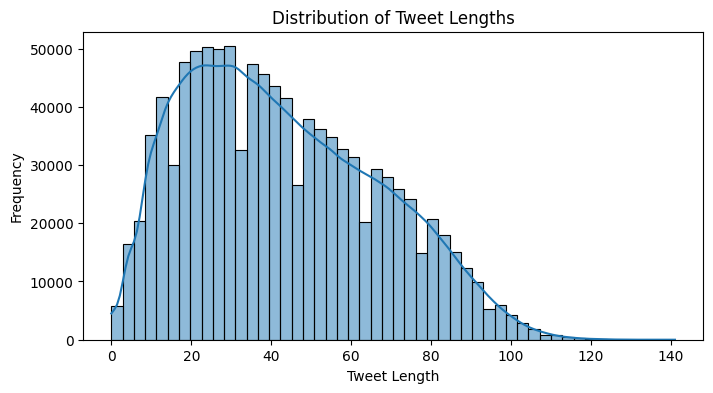

In [34]:
#Analysing the lenght of the tweets
#creating a new column for legth of tweet
df['tweet_length'] = df['processed_text'].apply(len)
plt.figure(figsize=(8,4))
sns.histplot(df['tweet_length'], bins=50, kde=True)
plt.title('Distribution of Tweet Lengths')
plt.xlabel('Tweet Length')
plt.ylabel('Frequency')
plt.show()

In [35]:
import pandas as pd
from collections import Counter
# Count words for each sentiment
positive_counts = Counter(
    ' '.join(df[df['polarity of tweet'] == 'positive']['processed_text']).split()
)
negative_counts = Counter(
    ' '.join(df[df['polarity of tweet'] == 'negative']['processed_text']).split()
)
# Get top 10 words for each sentiment
top_positive = positive_counts.most_common(10)
top_negative = negative_counts.most_common(10)
top_words_df = pd.DataFrame({
    'Top Positive Words': [word for word, count in top_positive],
    'Frequency (Positive)': [count for word, count in top_positive],
    'Top Negative Words': [word for word, count in top_negative],
    'Frequency (Negative)': [count for word, count in top_negative]
})
#Display
top_words_df




,Top Positive Words,Frequency (Positive),Top Negative Words,Frequency (Negative)
0,im,22775,im,102965
1,good,19871,day,50060
2,day,18914,get,47836
3,love,14659,go,47634
4,like,11872,work,45568
5,u,11521,dont,45128
6,get,11387,cant,43771
7,thanks,11084,like,41147
8,time,10307,today,36893
9,lol,9939,want,34032


In [36]:
from collections import Counter

# Separate positive and negative words
positive_words = ' '.join(df[df['polarity of tweet'] == 'positive']['processed_text']).split()
negative_words = ' '.join(df[df['polarity of tweet'] == 'negative']['processed_text']).split()

# (Optional) print check
print("Positive words sample:", positive_words[:10])
print("Negative words sample:", negative_words[:10])

!pip install wordcloud


Positive words sample: ['love', 'u', 'guy', 'r', 'best', 'im', 'meeting', 'one', 'besties', 'tonight']
Negative words sample: ['upset', 'cant', 'update', 'facebook', 'texting', 'might', 'cry', 'result', 'school', 'today']



[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


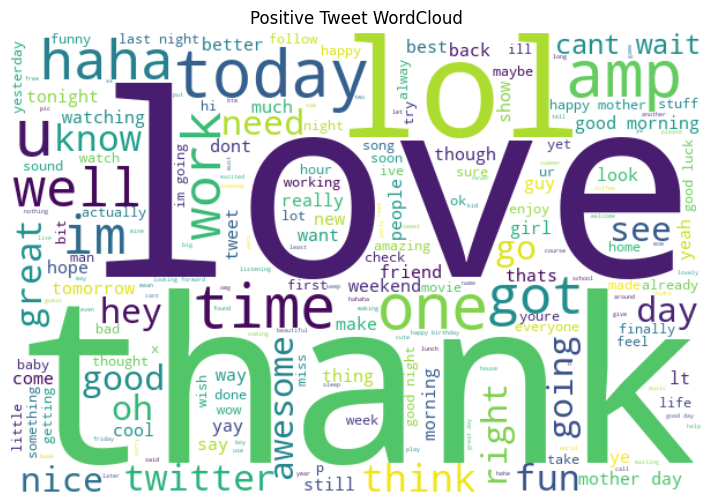

In [37]:
#Word clouds for positive tweets
from wordcloud import WordCloud
wc_pos = WordCloud(width=600, height=400, background_color='white').generate(' '.join(positive_words))
plt.figure(figsize=(10,6))
plt.imshow(wc_pos, interpolation='bilinear')
plt.axis('off')
plt.title("Positive Tweet WordCloud")
plt.show()

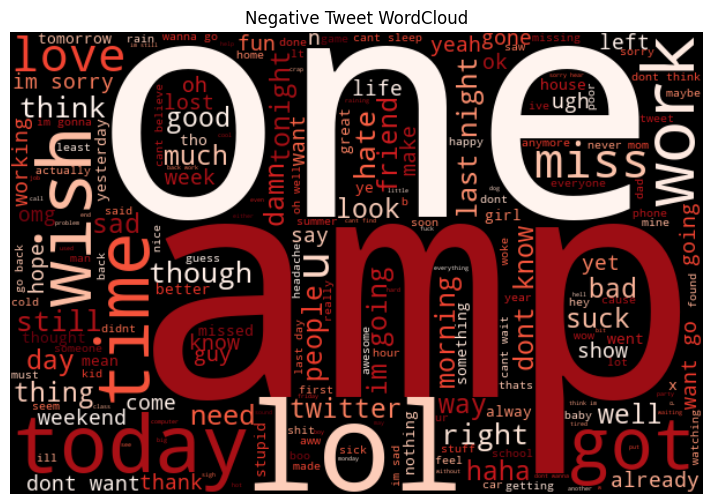

In [38]:
# word cloud for negative tweets
wc_neg = WordCloud(width=600, height=400, background_color='black', colormap='Reds').generate(' '.join(negative_words))
plt.figure(figsize=(10,6))
plt.imshow(wc_neg, interpolation='bilinear')
plt.axis('off')
plt.title("Negative Tweet WordCloud")
plt.show()


In [39]:
#checking for the remaining missing values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
polarity of tweet    0
text of the tweet    0
clean text           0
clean_text           0
processed_text       0
tweet_length         0
dtype: int64


In [40]:
#BIGRAM AND TRIGRAM ANALYSIS
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
# Positive Bigrams
vectorizer_pos = CountVectorizer(ngram_range=(2,2), stop_words='english')
bigrams_pos = vectorizer_pos.fit_transform(df[df['polarity of tweet']=='positive']['processed_text'])
sum_words_pos = bigrams_pos.sum(axis=0)
words_freq_pos = [(word, sum_words_pos[0, idx]) for word, idx in vectorizer_pos.vocabulary_.items()]
words_freq_pos = sorted(words_freq_pos, key=lambda x:x[1], reverse=True)[:10]
# Negative Bigrams
vectorizer_neg = CountVectorizer(ngram_range=(2,2), stop_words='english')
bigrams_neg = vectorizer_neg.fit_transform(df[df['polarity of tweet']=='negative']['processed_text'])
sum_words_neg = bigrams_neg.sum(axis=0)
words_freq_neg = [(word, sum_words_neg[0, idx]) for word, idx in vectorizer_neg.vocabulary_.items()]
words_freq_neg = sorted(words_freq_neg, key=lambda x:x[1], reverse=True)[:10]
# Combine into a single DataFrame
bigrams_combined_df = pd.DataFrame({
    'Top Positive Bigrams': [word for word, count in words_freq_pos],
    'Frequency (Positive)': [count for word, count in words_freq_pos],
    'Top Negative Bigrams': [word for word, count in words_freq_neg],
    'Frequency (Negative)': [count for word, count in words_freq_neg]
})
bigrams_combined_df


,Top Positive Bigrams,Frequency (Positive),Top Negative Bigrams,Frequency (Negative)
0,good morning,2903,feel like,6503
1,mother day,2660,dont know,6272
2,happy mother,1974,im going,5923
3,im going,1465,im sorry,5610
4,good night,1270,dont want,5146
5,looking forward,1208,look like,4362
6,good luck,1207,im gonna,3938
7,good day,990,dont think,3381
8,happy birthday,987,im sad,2931
9,great day,971,dont like,2750


In [41]:
#special charaters tweets
# Count exclamation marks and question marks
df['exclamation_count'] = df['text of the tweet'].apply(lambda x: x.count('!'))
df['question_count'] = df['text of the tweet'].apply(lambda x: x.count('?'))
# summary table
special_chars_df = df[['exclamation_count', 'question_count']].describe().transpose()
special_chars_df


,count,mean,std,min,25%,50%,75%,max
exclamation_count,1048572.0,0.520508,1.298181,0.0,0.0,0.0,1.0,111.0
question_count,1048572.0,0.153662,0.908693,0.0,0.0,0.0,0.0,110.0


In [42]:
# Extract hashtags
hashtags = df['text of the tweet'].str.findall(r'#\w+')
hashtags = [tag for sublist in hashtags for tag in sublist]
# Top 10 hashtags
top_hashtags_df = pd.Series(hashtags).value_counts().head(10).reset_index()
top_hashtags_df.columns = ['Hashtag', 'Frequency']
top_hashtags_df


,Hashtag,Frequency
0,#fb,1214
1,#followfriday,949
2,#squarespace,629
3,#iranelection,315
4,#fail,287
5,#1,278
6,#asot400,264
7,#2,217
8,#FollowFriday,191
9,#inaperfectworld,183


In [43]:
#CORRELATION BETWEEN TWEET LENGTH AND SENTIMENT
df['word_count'] = df['processed_text'].apply(lambda x: len(x.split()))
# Average tweet length and word count per sentiment
length_sentiment_df = df.groupby('polarity of tweet')[['tweet_length','word_count']].mean().reset_index()
length_sentiment_df.columns = ['Sentiment', 'Average Tweet Length', 'Average Word Count']
length_sentiment_df



,Sentiment,Average Tweet Length,Average Word Count
0,negative,43.255803,7.350048
1,positive,41.804193,6.968810


In [44]:
df.columns


Index(['polarity of tweet', 'text of the tweet', 'clean text', 'clean_text',
       'processed_text', 'tweet_length', 'exclamation_count', 'question_count',
       'word_count'],
      dtype='object')

In [45]:
#FEATURE ENGINEERING
#importing the required libraries
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

In [48]:
#FEATURE ENGINEERING
#Feature Extraction(TF-IDF)
tfidf = TfidfVectorizer(max_features=5000)  # You can adjust max_features
X = tfidf.fit_transform(df['processed_text'])
print("Feature matrix shape:", X.shape)

Feature matrix shape: (1048572, 5000)


In [47]:
#LABEL ENCODING
le = LabelEncoder()
y = le.fit_transform(df['polarity of tweet'])  # positive=1, negative=0
print("Encoded labels:", set(y))

Encoded labels: {0, 1}


In [49]:
#using small or 50k datas
df_sample = df.sample(n=50000, random_state=42)
X_sample = tfidf.fit_transform(df_sample['processed_text'])
y_sample = le.fit_transform(df_sample['polarity of tweet'])


In [50]:
from sklearn.model_selection import train_test_split
# Split sample data
X_train, X_test, y_train, y_test = train_test_split(
    X_sample, y_sample, test_size=0.2, random_state=42, stratify=y_sample
)
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 40000
Testing samples: 10000


In [51]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
# Defining the models
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Linear SVM": LinearSVC()
}


In [52]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
#  empty list to store results
results_list = []
# Training the  each model and collect metrics
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)   
    results_list.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred, average='weighted'), 4),
        "Recall": round(recall_score(y_test, y_pred, average='weighted'), 4),
        "F1-Score": round(f1_score(y_test, y_pred, average='weighted'), 4)
    })


Training Naive Bayes...
Training Logistic Regression...
Training Linear SVM...


In [53]:
import pandas as pd
# Convert results to DataFrame
results_df = pd.DataFrame(results_list)
# Display results
results_df


,Model,Accuracy,Precision,Recall,F1-Score
0,Naive Bayes,0.8018,0.8134,0.8018,0.7492
1,Logistic Regression,0.8209,0.8100,0.8209,0.7978
2,Linear SVM,0.8107,0.7964,0.8107,0.7982



Naive Bayes - Confusion Matrix


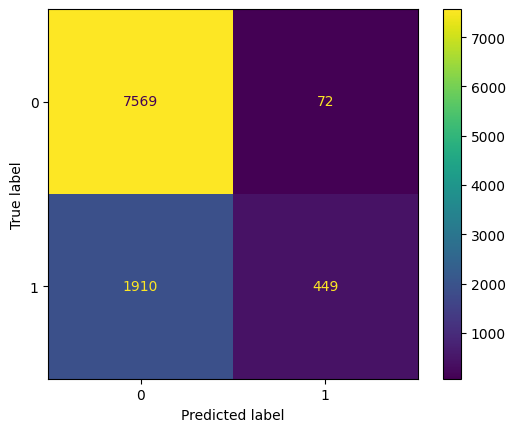


Logistic Regression - Confusion Matrix


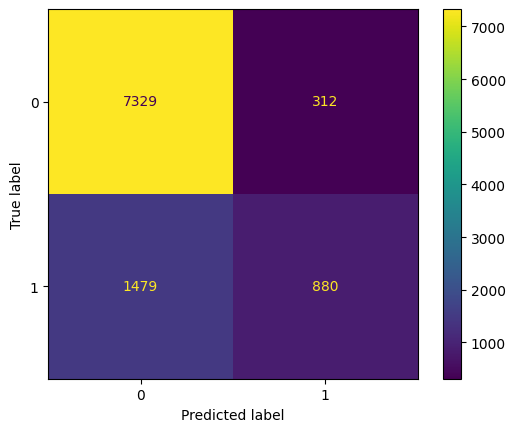


Linear SVM - Confusion Matrix


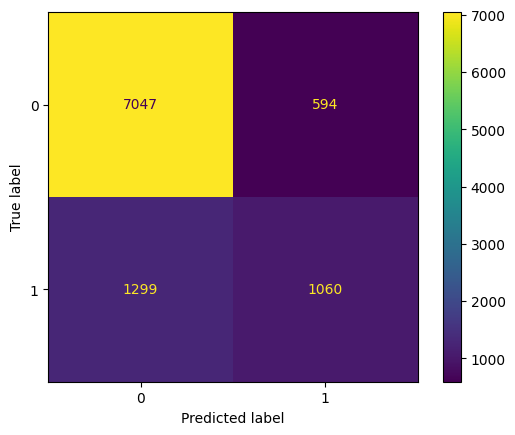

In [54]:
#confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
for name, model in models.items():
    print(f"\n{name} - Confusion Matrix")
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
    plt.show()


In [55]:
#best model
import pickle
# Find the model with the highest accuracy
best_model_name = results_df.loc[results_df['Accuracy'].idxmax(), 'Model']
best_model = models[best_model_name]
print(f"Best Model: {best_model_name} with Accuracy = {results_df['Accuracy'].max()}")
# Save the best model
with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# Save the TF-IDF vectorizer
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)
print("Best model and TF-IDF vectorizer saved successfully!")


Best Model: Logistic Regression with Accuracy = 0.8209
Best model and TF-IDF vectorizer saved successfully!


In [56]:
# Example: Predict sentiment on new tweets
new_tweets = ["I love this product!", "This is terrible!"]
# Load TF-IDF vectorizer 
# with open('tfidf_vectorizer.pkl', 'rb') as f:
#     tfidf = pickle.load(f)
# Transform new tweets
new_tfidf = tfidf.transform(new_tweets)
# Predict using the best model
predictions = le.inverse_transform(best_model.predict(new_tfidf))
for tweet, pred in zip(new_tweets, predictions):
    print(f"Tweet: {tweet}\nPredicted Sentiment: {pred}\n")


Tweet: I love this product!
Predicted Sentiment: positive

Tweet: This is terrible!
Predicted Sentiment: negative



In [58]:
# If needed, load saved model and vectorizer
import pickle

with open('best_model.pkl', 'rb') as f:
    best_model = pickle.load(f)
with open('tfidf_vectorizer.pkl', 'rb') as f:
    tfidf = pickle.load(f)
# Ask user for a tweet
user_tweet = input("Enter a tweet to predict its sentiment: ")
# Preprocess the tweet using the same cleaning & preprocessing functions
def clean_tweet(text):
    import re
    text = str(text).lower()
    text = re.sub(r'http\S+|www.\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text
def preprocess_text(text):
    from nltk.corpus import stopwords
    from nltk.stem import WordNetLemmatizer
    import nltk
    nltk.download('stopwords', quiet=True)
    nltk.download('wordnet', quiet=True)
    nltk.download('omw-1.4', quiet=True)
    
    stop_words = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()
    
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return ' '.join(words)
# Preprocess the user tweet
cleaned_tweet = clean_tweet(user_tweet)
processed_tweet = preprocess_text(cleaned_tweet)
# Transform using TF-IDF and predict
tweet_tfidf = tfidf.transform([processed_tweet])
predicted_sentiment = le.inverse_transform(best_model.predict(tweet_tfidf))[0]
print(f"\nPredicted Sentiment: {predicted_sentiment}")


Enter a tweet to predict its sentiment:  i hate it totally!!!!



Predicted Sentiment: negative


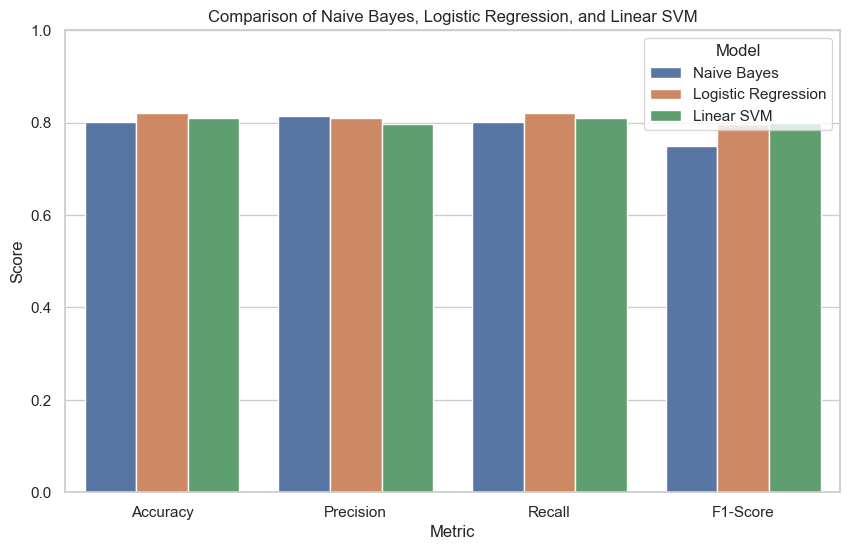

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="whitegrid")

# Melt the results_df for easier plotting
results_melted = results_df.melt(id_vars='Model', 
                                 value_vars=['Accuracy','Precision','Recall','F1-Score'],
                                 var_name='Metric', 
                                 value_name='Score')
# Plot
plt.figure(figsize=(10,6))
sns.barplot(x='Metric', y='Score', hue='Model', data=results_melted)
plt.title('Comparison of Naive Bayes, Logistic Regression, and Linear SVM')
plt.ylim(0,1)
plt.ylabel('Score')
plt.show()


C:\Users\okkk\AppData\Local\Temp\ipykernel_13264\1449761785.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=results_df, palette='pastel')


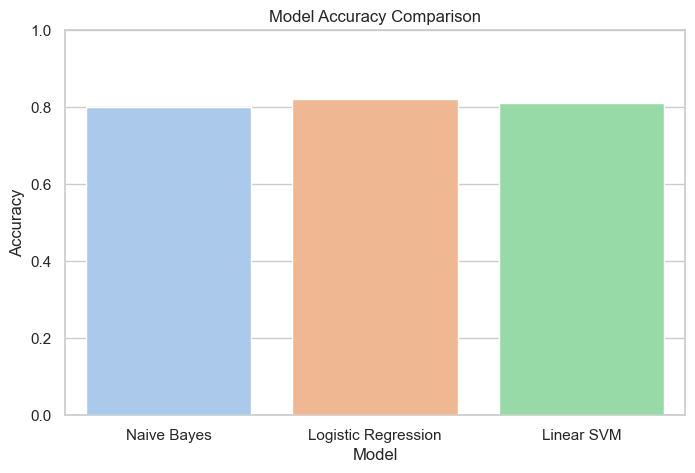

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns
# Set style
sns.set(style="whitegrid")
plt.figure(figsize=(8,5))
sns.barplot(x='Model', y='Accuracy', data=results_df, palette='pastel')
plt.title('Model Accuracy Comparison')
plt.ylim(0,1)
plt.ylabel('Accuracy')
plt.show()


In [62]:
#ADVANCE ALGORITHMS
#preprocessing and tokenization
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
# Parameters
max_words = 10000     
max_len = 50         
embedding_dim = 100
# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(df_sample['polarity of tweet'])  # 0=negative, 1=positive
# Tokenize tweets
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(df_sample['processed_text'])
X_seq = tokenizer.texts_to_sequences(df_sample['processed_text'])
X_pad = pad_sequences(X_seq, maxlen=max_len)
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_pad, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)


In [67]:
model = Sequential()
model.add(Embedding(input_dim=max_words, output_dim=embedding_dim, input_shape=(max_len,)))
model.add(LSTM(128))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))
model.summary()



C:\Users\okkk\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\embedding.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)              │ (None, 50, 100)             │       1,000,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 128)                 │         117,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,117,377 (4.26 MB)

 Trainable params: 1,117,377 (4.26 MB)

 Non-trainable params: 0 (0.00 B)

In [69]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

# Build the model
model = Sequential()
model.add(Embedding(input_dim=max_words, output_dim=embedding_dim, input_shape=(max_len,)))
model.add(LSTM(128))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))  # binary classification

# **Compile the model** <- this is required before training
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Now you can train
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)



Epoch 1/5
563/563 ━━━━━━━━━━━━━━━━━━━━ 80s 135ms/step - accuracy: 0.7840 - loss: 0.4896 - val_accuracy: 0.8210 - val_loss: 0.4111
Epoch 2/5
563/563 ━━━━━━━━━━━━━━━━━━━━ 74s 131ms/step - accuracy: 0.8550 - loss: 0.3458 - val_accuracy: 0.8155 - val_loss: 0.4203
Epoch 3/5
563/563 ━━━━━━━━━━━━━━━━━━━━ 78s 138ms/step - accuracy: 0.8748 - loss: 0.3006 - val_accuracy: 0.8117 - val_loss: 0.4341
Epoch 4/5
563/563 ━━━━━━━━━━━━━━━━━━━━ 66s 118ms/step - accuracy: 0.8982 - loss: 0.2466 - val_accuracy: 0.8105 - val_loss: 0.4858
Epoch 5/5
563/563 ━━━━━━━━━━━━━━━━━━━━ 77s 137ms/step - accuracy: 0.9180 - loss: 0.2012 - val_accuracy: 0.8012 - val_loss: 0.5855


In [71]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy:.4f}")


313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 45ms/step - accuracy: 0.7814 - loss: 1.0708
Test Accuracy: 0.7822


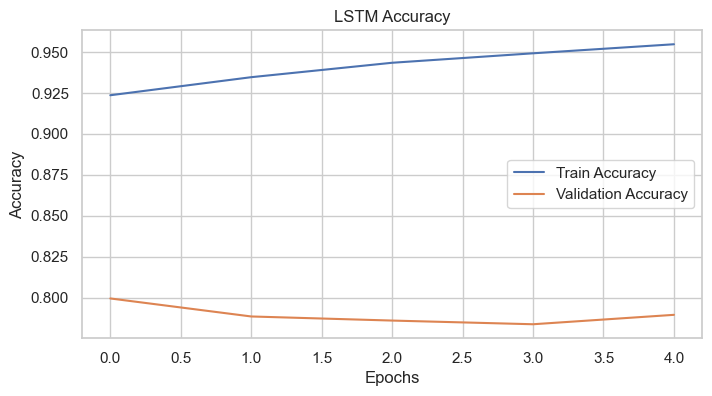

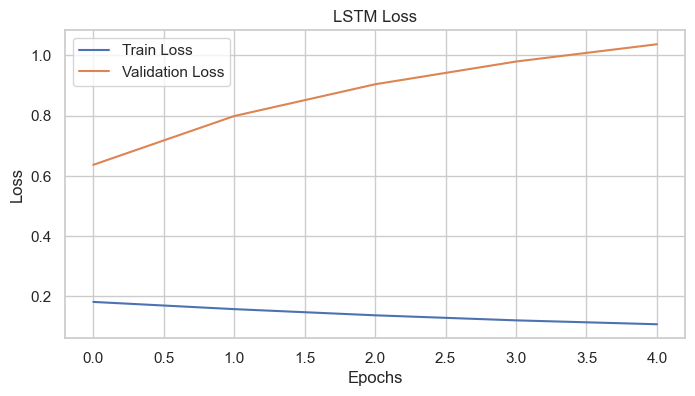

In [72]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.figure(figsize=(8,4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('LSTM Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Loss plot
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [73]:
def predict_tweet(tweet):
    import re
    from nltk.stem import WordNetLemmatizer
    lemmatizer = WordNetLemmatizer()
    
    # Clean
    text = tweet.lower()
    text = re.sub(r'http\S+|www.\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Lemmatize
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words]
    text_processed = ' '.join(words)
    
    # Tokenize + pad
    seq = tokenizer.texts_to_sequences([text_processed])
    pad = pad_sequences(seq, maxlen=max_len)
    
    # Predict
    pred = model.predict(pad)[0][0]
    return 'positive' if pred >= 0.5 else 'negative'

# Example
tweet = "I hate waiting in long lines!"
print(f"Tweet: {tweet}\nPredicted Sentiment: {predict_tweet(tweet)}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 530ms/step
Tweet: I hate waiting in long lines!
Predicted Sentiment: negative


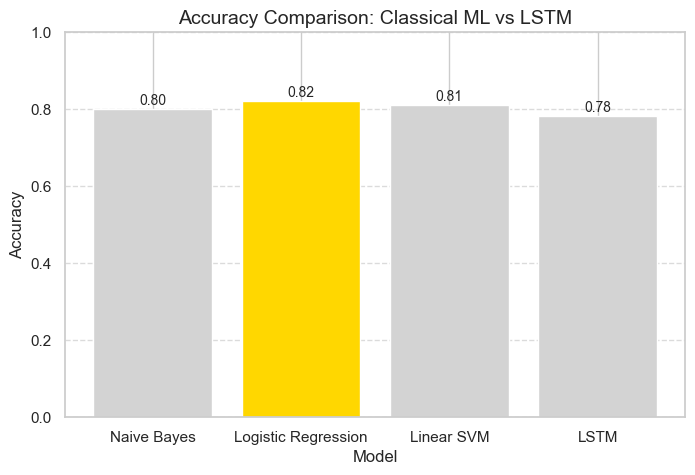

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Accuracy dictionary
accuracy_dict = {
    'Naive Bayes': nb_acc,
    'Logistic Regression': lr_acc,
    'Linear SVM': svm_acc,
    'LSTM': accuracy  # from model.evaluate()
}
# Create DataFrame
acc_df = pd.DataFrame(list(accuracy_dict.items()), columns=['Model', 'Accuracy'])
# Colors: highlight best model
best_index = acc_df['Accuracy'].idxmax()
colors = ['lightgray'] * len(acc_df)
colors[best_index] = '#FFD700'  # Gold for best
# Plot bar chart
plt.figure(figsize=(8,5))
bars = plt.bar(acc_df['Model'], acc_df['Accuracy'], color=colors)
plt.title('Accuracy Comparison: Classical ML vs LSTM', fontsize=14)
plt.ylim(0,1)
plt.ylabel('Accuracy')
plt.xlabel('Model')
plt.grid(axis='y', linestyle='--', alpha=0.7)
# Optional: add accuracy labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.2f}', ha='center', fontsize=10)
plt.show()



In [85]:
sample_tweets = df_sample['text of the tweet'].sample(10, random_state=42)
for tweet in sample_tweets:
    print(f"Tweet: {tweet}")
    print(f"Predicted Sentiment (Best Model): {predict_tweet(tweet)}\n")


Tweet: @nzben My PC case (for the PVR) requires low profile TV cards and the case can't fit a 2nd card in easily whilst not overheating 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
Predicted Sentiment (Best Model): negative

Tweet: Whats my fucking problem. 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
Predicted Sentiment (Best Model): negative

Tweet: @ZeonJobs I dont understand what your crawler agent is, but thanks for the jobs 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
Predicted Sentiment (Best Model): negative

Tweet: Catching up on earplug inventory.  Attending a memorial service for a friend's wife.  
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
Predicted Sentiment (Best Model): negative

Tweet: @GOLDLINEENT What was for Me? I missed it reading about the life of James Dean 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
Predicted Sentiment (Best Model): negative

Tweet: Need a book to get lost in my thoughts. I wish i hadn't read that. Damn Kevin. 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
Predicted Sentiment 

In [86]:
tweet = "I am so happy and excited about this amazing day!"
print(predict_tweet(tweet))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
positive


In [87]:
import random
# Take a sample of 10 tweets
sample_tweets = df_sample['text of the tweet'].sample(100, random_state=42).tolist()
# Shuffle the tweets
random.shuffle(sample_tweets)
# Predict sentiment for each tweet
for tweet in sample_tweets:
    print(f"Tweet: {tweet}")
    print(f"Predicted Sentiment (Best Model): {predict_tweet(tweet)}\n")


Tweet: @MissKatiePrice  Hellooo katie...i have watched your show all the way through...going to miss you and pete  hope everything works well x x
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
Predicted Sentiment (Best Model): negative

Tweet: http://twitpic.com/696cc - I used to own a business. 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
Predicted Sentiment (Best Model): negative

Tweet: @revolutioniran : trust me! i have cried all day! 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
Predicted Sentiment (Best Model): negative

Tweet: @nelliesf got in about an hour ago! Home is great, but I'm having SD withdrawals 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
Predicted Sentiment (Best Model): positive

Tweet: wow. Fat ass hangover. 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
Predicted Sentiment (Best Model): negative

Tweet: I really miss all of my aber 675 peeps  Minnesota has to happen this summer!
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
Predicted Sentiment (Best Model): negative

Tweet: I abuse my husband while we sle

In [89]:
# Function to predict sentiment from user input
def predict_user_tweet(tweet):
    import re
    from nltk.stem import WordNetLemmatizer
    from tensorflow.keras.preprocessing.sequence import pad_sequences
    
    lemmatizer = WordNetLemmatizer()
    
    # 1. Clean the tweet
    text = tweet.lower()
    text = re.sub(r'http\S+|www.\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    # 2. Lemmatize
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words]
    text_processed = ' '.join(words)
    
    # 3. Tokenize + pad (use same tokenizer and max_len as training)
    seq = tokenizer.texts_to_sequences([text_processed])
    pad_seq = pad_sequences(seq, maxlen=max_len)
    
    # 4. Predict
    pred_prob = model.predict(pad_seq)[0][0]
    pred_label = 'positive' if pred_prob >= 0.5 else 'negative'
    
    print(f"\nTweet: {tweet}")
    print(f"Predicted Sentiment: {pred_label}")

# Example: Interactive input
user_tweet = input("Enter a tweet to predict sentiment: ")
predict_user_tweet(user_tweet)


Enter a tweet to predict sentiment:  i love you baby !


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step

Tweet: i love you baby !
Predicted Sentiment: positive


In [90]:
#BILSTM
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
# Parameters
max_words = 10000      # vocabulary size
max_len = 50           # max tweet length
embedding_dim = 100
# Use the processed_text column from your 50k sample
texts = df_sample['processed_text'].tolist()
labels = le.fit_transform(df_sample['polarity of tweet'])  # 0=negative,1=positive
# Tokenizer
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)
X = pad_sequences(sequences, maxlen=max_len)
y = labels
# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [94]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dropout, Dense

model = Sequential()
model.add(Embedding(input_dim=max_words, output_dim=embedding_dim))
model.add(Bidirectional(LSTM(128)))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

# Build the model with input shape (batch_size, sequence_length)
model.build(input_shape=(None, max_len))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()




Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_8 (Embedding)              │ (None, 50, 100)             │       1,000,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_3 (Bidirectional)      │ (None, 256)                 │         234,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 1)                   │             257 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,234,753 (4.71 MB)

 Trainable params: 1,234,753 (4.71 MB)

 Non-trainable params: 0 (0.00 B)

In [95]:
# Training the BiLSTM model
history = model.fit(
    X_train, y_train,
    epochs=5,            # adjust for time efficiency
    batch_size=64,
    validation_split=0.1
)


Epoch 1/5
563/563 ━━━━━━━━━━━━━━━━━━━━ 58s 96ms/step - accuracy: 0.7846 - loss: 0.4877 - val_accuracy: 0.8217 - val_loss: 0.3965
Epoch 2/5
563/563 ━━━━━━━━━━━━━━━━━━━━ 54s 95ms/step - accuracy: 0.8542 - loss: 0.3446 - val_accuracy: 0.8200 - val_loss: 0.4101
Epoch 3/5
563/563 ━━━━━━━━━━━━━━━━━━━━ 53s 95ms/step - accuracy: 0.8786 - loss: 0.2934 - val_accuracy: 0.8163 - val_loss: 0.4443
Epoch 4/5
563/563 ━━━━━━━━━━━━━━━━━━━━ 53s 95ms/step - accuracy: 0.9008 - loss: 0.2396 - val_accuracy: 0.8090 - val_loss: 0.5178
Epoch 5/5
563/563 ━━━━━━━━━━━━━━━━━━━━ 55s 97ms/step - accuracy: 0.9165 - loss: 0.1991 - val_accuracy: 0.8037 - val_loss: 0.6233


In [96]:
# Evaluate model on X_test
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy:.4f}")


313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.8014 - loss: 0.6234
Test Accuracy: 0.7994


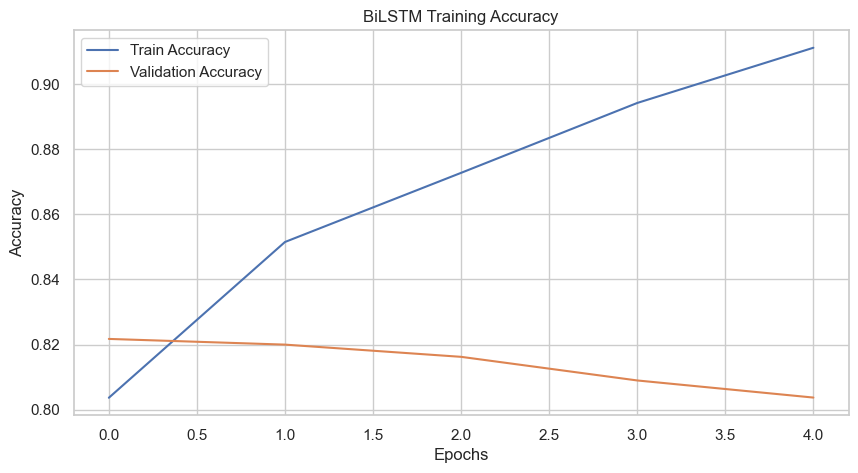

In [97]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('BiLSTM Training Accuracy')
plt.legend()
plt.show()


In [104]:
def predict_user_tweet(tweet):
    import re
    from nltk.stem import WordNetLemmatizer
    from tensorflow.keras.preprocessing.sequence import pad_sequences

    lemmatizer = WordNetLemmatizer()

    # 1. Clean
    text = tweet.lower()
    text = re.sub(r'http\S+|www.\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()

    # 2. Lemmatize
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words]
    text_processed = ' '.join(words)

    # 3. Tokenize & pad
    seq = tokenizer.texts_to_sequences([text_processed])
    pad_seq = pad_sequences(seq, maxlen=max_len)

    # 4. Predict
    pred_prob = model.predict(pad_seq)[0][0]
    pred_label = 'positive' if pred_prob >= 0.5 else 'negative'
    print(f"\nTweet: {tweet}")
    print(f"Predicted Sentiment: {pred_label}")

# Example usage
user_tweet = input("Enter a tweet to predict sentiment: ")
predict_user_tweet(user_tweet)




Enter a tweet to predict sentiment:  it is beautiful


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step

Tweet: it is beautiful
Predicted Sentiment: positive


In [106]:
import pandas as pd
import re
from nltk.stem import WordNetLemmatizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from IPython.display import display

lemmatizer = WordNetLemmatizer()

def predict_multiple_tweets_styled(tweets, model, tokenizer, max_len=50):
    results = []

    for tweet in tweets:
        # 1. Clean
        text = tweet.lower()
        text = re.sub(r'http\S+|www.\S+', '', text)
        text = re.sub(r'@\w+', '', text)
        text = re.sub(r'[^a-z\s]', '', text)
        text = re.sub(r'\s+', ' ', text).strip()

        # 2. Lemmatize
        words = text.split()
        words = [lemmatizer.lemmatize(w) for w in words]
        text_processed = ' '.join(words)

        # 3. Tokenize & pad
        seq = tokenizer.texts_to_sequences([text_processed])
        pad_seq = pad_sequences(seq, maxlen=max_len)

        # 4. Predict
        pred_prob = model.predict(pad_seq, verbose=0)[0][0]
        pred_label = 'positive' if pred_prob >= 0.5 else 'negative'

        results.append({
            'Tweet': tweet,
            'Predicted Sentiment': pred_label,
            'Probability (Positive)': round(pred_prob, 4)
        })

    # Convert to DataFrame
    df_results = pd.DataFrame(results)

    # Style for better readability
    styled_df = df_results.style.set_properties(**{
        'white-space': 'pre-wrap',
        'text-align': 'left',
        'font-size': '12px',
        'width': '400px'
    }).background_gradient(subset=['Probability (Positive)'], cmap='RdYlGn')
    
    display(styled_df)
    return df_results

# Example tweets
sample_tweets = [
    "It's very good and bad but I love it",
    "I hate this weather",
    "Amazing day, feeling great!",
    "I am so sad and disappointed"
]

# Run predictions and display styled table
prediction_table = predict_multiple_tweets_styled(sample_tweets, model, tokenizer, max_len)


,Tweet,Predicted Sentiment,Probability (Positive)
0,It's very good and bad but I love it,negative,0.433900
1,I hate this weather,negative,0.001700
2,"Amazing day, feeling great!",positive,0.906900
3,I am so sad and disappointed,negative,0.000000


In [3]:
import pandas as pd
import re
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import hstack
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from IPython.display import display


In [4]:
# Load CSV (1.6M tweets)
url = r'C:\Users\okkk\Desktop\python programming project\twitterdata.csv'
df = pd.read_csv(url, encoding='latin-1', dtype=str)
# Rename columns
df.columns = ['polarity','id','date','query','user','text']
# Keep only relevant columns
df = df[['polarity','text']]
# Map polarity: 0 -> negative, 4 -> positive
df['polarity'] = df['polarity'].map({'0':'negative','4':'positive'})
# Feature enrichment: exclamations, questions, hashtags
df['exclamation_count'] = df['text'].str.count('!')
df['question_count'] = df['text'].str.count(r'\?')
df['hashtag_count'] = df['text'].str.count(r'#\w+')

df.head(10)


,polarity,text,exclamation_count,question_count,hashtag_count
0,negative,is upset that he can't update his Facebook by ...,1,0,0
1,negative,@Kenichan I dived many times for the ball. Man...,0,0,0
2,negative,my whole body feels itchy and like its on fire,0,0,0
3,negative,"@nationwideclass no, it's not behaving at all....",0,1,0
4,negative,@Kwesidei not the whole crew,0,0,0
5,negative,Need a hug,0,0,0
6,negative,@LOLTrish hey long time no see! Yes.. Rains a...,1,1,0
7,negative,I just re-pierced my ears,0,0,0
8,negative,@caregiving I couldn't bear to watch it. And ...,0,0,0
9,negative,"@octolinz16 It it counts, idk why I did either...",0,0,0


In [5]:
# TF-IDF vectorizer
tfidf = TfidfVectorizer(max_features=50000, stop_words='english')
X_text = tfidf.fit_transform(df['text'])

# Combine TF-IDF with extra features
X_extra = df[['exclamation_count','question_count','hashtag_count']].values
X = hstack([X_text, X_extra])  # shape = (1.6M, 50003)

# Encode labels
le = LabelEncoder()
y = le.fit_transform(df['polarity'])

print("Final feature matrix shape:", X.shape)


Final feature matrix shape: (1048572, 50003)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)
print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])


Training samples: 943714
Test samples: 104858


In [7]:
lr_model = LogisticRegression(max_iter=300)
lr_model.fit(X_train, y_train)
print("Model trained on all 1.6M tweets with extra features.")


Model trained on all 1.6M tweets with extra features.


In [8]:
y_pred = lr_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy on test set: {acc:.4f}")


Accuracy on test set: 0.8365


Enter multiple tweets (type 'DONE' to finish):


 I LOVE YOU
 its horrible!!!!
 i hate this totally
 its happy day...
 DONE


,Tweet,Predicted Sentiment,Probability (Positive)
0,I LOVE YOU,positive,0.860500
1,its horrible!!!!,negative,0.994100
2,i hate this totally,negative,0.980800
3,its happy day...,positive,0.871300


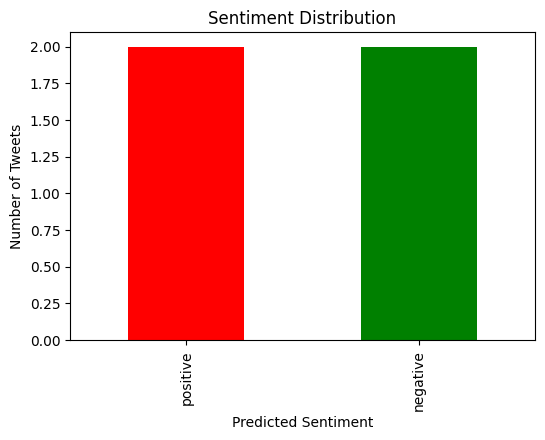

In [9]:
def predict_tweets_dashboard():
    print("Enter multiple tweets (type 'DONE' to finish):")
    tweets = []
    while True:
        tweet = input()
        if tweet.strip().upper() == 'DONE':
            break
        elif tweet.strip() != '':
            tweets.append(tweet)
    
    if len(tweets) == 0:
        print("No tweets entered.")
        return
    
    results = []
    for tweet in tweets:
        # Feature enrichment
        exclamation_count = tweet.count('!')
        question_count = tweet.count('?')
        hashtag_count = len(re.findall(r'#\w+', tweet))
        
        # TF-IDF
        seq = tfidf.transform([tweet])
        
        # Combine with extra features
        X_input = hstack([seq, np.array([[exclamation_count, question_count, hashtag_count]])])
        
        # Predict
        pred_class = lr_model.predict(X_input)[0]
        pred_prob = lr_model.predict_proba(X_input)[0][pred_class]
        label = le.inverse_transform([pred_class])[0]
        
        results.append({
            'Tweet': tweet,
            'Predicted Sentiment': label,
            'Probability (Positive)': round(pred_prob,4)
        })
    
    # Display table with color gradient
    df_results = pd.DataFrame(results)
    styled_df = df_results.style.set_properties(**{
        'white-space': 'pre-wrap',
        'text-align': 'left',
        'font-size': '12px',
        'width': '400px'
    }).background_gradient(subset=['Probability (Positive)'], cmap='RdYlGn')
    display(styled_df)
    
    # Bar chart summary
    summary = df_results['Predicted Sentiment'].value_counts()
    plt.figure(figsize=(6,4))
    summary.plot(kind='bar', color=['red','green'])
    plt.title("Sentiment Distribution")
    plt.ylabel("Number of Tweets")
    plt.show()

# Run this cell to start the dashboard
predict_tweets_dashboard()


In [10]:
pip install streamlit scikit-learn pandas matplotlib scipy


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
import os
import joblib
# Create the 'model' folder if it doesn't exist
os.makedirs('model', exist_ok=True)
# Save the trained components
joblib.dump(tfidf, 'model/tfidf_vectorizer.pkl')
joblib.dump(lr_model, 'model/logistic_model.pkl')
joblib.dump(le, 'model/label_encoder.pkl')
print("Models saved successfully in 'model/' folder.")



Models saved successfully in 'model/' folder.
